 # Workflow for a transformation pathway of a single node energy system with perfect foresight

 In this application of the ETHOS.FINE framework, a transformation pathway of a energy system is modeled and optimized.

 All classes which are available to the user are utilized and examples of the selection of different parameters within these classes are given.

 The workflow is structures as follows:
 1. Required packages are imported and the input data path is set
 2. An energy system model instance is created
 3. Commodity sources are added to the energy system model
 4. Commodity conversion components are added to the energy system model
 5. Commodity storages are added to the energy system model
 6. Commodity sinks are added to the energy system model
 7. Material sinks are added to the energy system model
 8. Material sources are addeed to the energy system model
 9. Material conversions are added to the energy system model for recycling processes
 10. The energy system model is optimized
 11. Selected optimization results are presented


 # 1. Import required packages and set input data path

 The ETHOS.FINE framework is imported which provides the required classes and functions for modeling the energy system.

In [29]:
import fine as fn
from getData import getData
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


cwd = Path.cwd()
data = getData()

 # 2. Create an energy system model instance

 The structure of the energy system model is given by the considered locations, commodities, the number of time steps as well as the hours per time step.

 The commodities are specified by a unit (i.e. 'GW_electric', 'GW_H2lowerHeatingValue', 'Mio. t CO2/h') which can be given as an energy or mass unit per hour. Furthermore, the cost unit and length unit are specified.

In [2]:
locations = {"GermanyRegion"}
commodityUnitsDict = {"electricity": r"GW$_{el}$"}
commodities = {"electricity"}
materials = {"steel"}
materialUnitsDict = {"steel": "tons/h"}

numberOfTimeSteps = 8760
hoursPerTimeStep = 1


 # 2.1 define Transformation Pathway parameters

 Transformation Pathway Analyses can be run by setting a number of investment periods
 larger than 1, which is the default value and results in a single year optimization.

In [3]:
numberOfInvestmentPeriods = 5
startYear = 2020
interval = 1
# MaterialStorage currently requires optimization without time series aggregation.
includeMaterialStorage = True


In [4]:
pathwayBalanceLimit = pd.DataFrame(
    columns=["GermanyRegion", "Total", "lowerBound"],
    index=["Steel_Resources"],
)
pathwayBalanceLimit.loc["Steel_Resources"] = [None, None, False]


In [5]:
esM = fn.EnergySystemModel(
    locations=locations,
    commodities=commodities,
    materials=materials,
    numberOfInvestmentPeriods=numberOfInvestmentPeriods,
    startYear=startYear,
    investmentPeriodInterval=interval,
    numberOfTimeSteps=8760,
    commodityUnitsDict=commodityUnitsDict,
    materialUnitsDict=materialUnitsDict,
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
    pathwayBalanceLimit=pathwayBalanceLimit,
)

 # 3. Add commodity sources to the energy system model

 ## 3.1. Electricity sources

 ### Wind onshore

 change weather conditions for the different investment periods

In [6]:
operationRateMax = {
    2020: 1.2 * data["Wind (onshore), operationRateMax"],
    2021: 1.2 * data["Wind (onshore), operationRateMax"],
    2022: 1.2 * data["Wind (onshore), operationRateMax"],
    2023: 1.2 * data["Wind (onshore), operationRateMax"],
    2024: 1.2 * data["Wind (onshore), operationRateMax"],
}


 add wind onshore source to esM

In [7]:
esM.add(
    fn.Source(
        esM=esM,
        name="windonshore",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=operationRateMax,
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=3.1,
        opexPerCapacity=3.1 * 0.02,
        interestRate=0.08,
        economicLifetime=1,
        technicalLifetime=1,
        materialIntensity={
            2020: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2021: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2022: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2023: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2024: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
        },
        materialCollection={
            2020: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2021: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2022: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2023: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2024: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
        },
    )
)


In [8]:
esM.add(
    fn.Source(
        esM=esM,
        name="windoffshore",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=operationRateMax,
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=3.1,
        opexPerCapacity=3.1 * 0.015,
        interestRate=0.08,
        economicLifetime=1,
        technicalLifetime=1,
        materialIntensity={
            2020: {
                "steel": pd.Series({"GermanyRegion": 4.1}),
            },
            2021: {
                "steel": pd.Series({"GermanyRegion": 4.1}),
            },
            2022: {
                "steel": pd.Series({"GermanyRegion": 4.1}),
            },
            2023: {
                "steel": pd.Series({"GermanyRegion": 4.1}),
            },
            2024: {
                "steel": pd.Series({"GermanyRegion": 4.1}),
            },
        },
        materialCollection={
            2020: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2021: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2022: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2023: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2024: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
        },
    )
)


 Full load hours:

In [9]:
data["Wind (onshore), operationRateMax"].sum()

np.float64(2300.4069071646272)

 # 4. Add conversion components to the energy system model

 ### Electrolyzers

 add component with constant invest and opex per capacity

 # 5. Add commodity storages to the energy system model

 ## 5.1. Electricity storage

 ### Lithium ion batteries

 The self discharge of a lithium ion battery is here described as 3% per month. The self discharge per hours is obtained using the equation (1-$\text{selfDischarge}_\text{hour})^{30*24\text{h}} = 1-\text{selfDischarge}_\text{month}$.

In [10]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Li-ion batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        cyclicLifetime=10000,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        doPreciseTsaModeling=False,
        investPerCapacity=0.151,
        opexPerCapacity=0.002,
        interestRate=0.08,
        economicLifetime=15,
    )
)

 ## 5.2. Hydrogen storage

 ### Hydrogen filled salt caverns
 The maximum capacity is here obtained by: dividing the given capacity (which is given for methane) by the lower heating value of methane and then multiplying it with the lower heating value of hydrogen.

 # 6. Add commodity sinks to the energy system model

 ## 6.1. Electricity sinks

 ### Electricity demand

 vary the demand with the years - increasing demand by 30% per year

In [11]:
electricityDemand = {
    2020: data["Electricity demand, operationRateFix"],
    2021: data["Electricity demand, operationRateFix"],
    2022: data["Electricity demand, operationRateFix"],
    2023: data["Electricity demand, operationRateFix"],
    2024: data["Electricity demand, operationRateFix"],
}

esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=electricityDemand,
    )
)


 ## 6.2. Hydrogen sinks

 ### Fuel cell electric vehicle (FCEV) demand

# 7. Add material sinks to the energy system model

In [12]:
esM.generationMaterialSinks()

Existing material sinks: set()
Missing materials sinks: {'steel'}
New sink added: Steel demand


# 8. Add material sources to the energy system model


## 8.1 Add primary material sources with pathway balance limit


In [13]:
steelSupplyOperationRateMax = {
    year: pd.DataFrame(
        0 if year in [2022, 2023] else 1,
        index=range(numberOfTimeSteps),
        columns=["GermanyRegion"],
    )
    for year in esM.investmentPeriodNames
}

esM.add(
    fn.Source(
        esM=esM,
        name="Steel supply",
        hasCapacityVariable=True,
        commodity="steel",
        operationRateMax=steelSupplyOperationRateMax,
        capacityMax={year: 0.1 for year in esM.investmentPeriodNames},
        pathwayBalanceLimitID="Steel_Resources",
    )
)


In [14]:
esM.generationSecondaryMaterialSources()

Scrap commodities : {'windoffshore_steel_scrap', 'windonshore_steel_scrap'}
Existing secondary material sources: set()
Missing secondary material sources: {'windoffshore_steel_scrap', 'windonshore_steel_scrap'}
New scrap source added: windoffshore_steel_scrap
New scrap source added: windonshore_steel_scrap
Existing secondary material sinks: set()
Missing secondary material sinks: {'windoffshore_steel_scrap', 'windonshore_steel_scrap'}
New scrap sink added: windoffshore_steel_scrap_rec
New scrap sink added: windonshore_steel_scrap_rec


# 9. Add material storages

Steel supply is constant, dispatchable and sufficiently elastic. Since storage has positive costs and cannot relieve a supply constraint, its optimal capacity should be zero in every investment period.


In [15]:
if includeMaterialStorage:
    esM.add(
        fn.MaterialStorage(
            esM=esM,
            name="Steel storage",
            commodity="steel",
            hasCapacityVariable=True,
            chargeEfficiency=1,
            dischargeEfficiency=1,
            selfDischarge=0,
            stateOfChargeBoundary="interInvestmentPeriodNotCyclic",
            investPerCapacity=1e-7,
            opexPerCapacity=2e-9,
            opexPerChargeOperation=1e-9,
            opexPerDischargeOperation=1e-9,
            interestRate=0.08,
            economicLifetime=30,
            technicalLifetime=30,
        )
    )


# 10. Add recycling plants

 # 11. Optimize energy system model

 All components are now added to the model and the model can be optimized. If the computational complexity of the optimization should be reduced, the time series data of the specified components can be clustered before the optimization and the parameter timeSeriesAggregation is set to True in the optimize call.

In [16]:
if not includeMaterialStorage:
    esM.aggregateTemporally(numberOfTypicalPeriods=30)


In [17]:
esM.optimize(
    timeSeriesAggregation=not includeMaterialStorage,
    solver="gurobi",
)


Declaring sets, variables and constraints for SourceSinkModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(4.4539 sec)

Declaring sets, variables and constraints for StorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(4.4020 sec)

Declaring sets, variables and constraints for MaterialStorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.5856 sec)

Declaring shared potential constraint...
		(0.0006 sec)

Declaring linked component quantity constraint...
		(0.0000 sec)

Declaring commodity balances...
		(2.3531 sec)

Declaring material demand constraints...
LHS_demand op_srcSnk[GermanyRegion,Steel demand,0,0,0] + op_srcSnk[GermanyRegion,Steel demand,0,0,1] + op_srcSnk[GermanyRegion,Steel demand,0,0,2] + op_srcSnk[GermanyRegion,Steel demand,0,0,3] + op_srcSnk[GermanyRegion,Steel demand,0,0,4] + op_srcSnk[GermanyRegion,Steel demand,0,0,5] + op_srcSnk[GermanyRegion,Steel demand,0,0,6] + op_

C:\Users\j.mutke\Desktop\programming\FINE_GitHub\FINE\fine\storage.py:2163: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(
C:\Users\j.mutke\Desktop\programming\FINE_GitHub\FINE\fine\storage.py:2163: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(
C:\Users\j.mutke\Desktop\programming\FINE_GitHub\FINE\fine\storage.py:2163: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(
C:\Users\j.mutke\Desktop\programming\FINE_GitHub\FINE\fine\storage.py:2163: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(
C:\Users\j.mutke\Desktop\programming\FINE_GitHub\FINE\fine\storage.py:2163: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(


for StorageModel ...  (9.2910sec)
for MaterialStorageModel ...(5.9571sec)
		(64.1798 sec)



 # 12. Selected results output

 ### Sources and Sink

 Show optimization summary

In [18]:
for year in esM.investmentPeriodNames:
    print(f"\n Results of SourceSinkModel for year {year}")
    print(esM.getOptimizationSummary("SourceSinkModel", outputLevel=2, ip=year))


 Results of SourceSinkModel for year 2020
                                                   GermanyRegion
Component          Property        Unit                         
Electricity demand operation       [GW$_{el}$*h/a]  30957.888055
                                   [GW$_{el}$*h]    30957.888055
Steel demand       operation       [tons/h*h/a]         69.55762
                                   [tons/h*h]           69.55762
Steel supply       capacity        [tons/h]                  0.1
                   commissioning   [tons/h]                  0.1
                   operation       [tons/h*h/a]         69.55762
                                   [tons/h*h]           69.55762
windoffshore       NPVcontribution [1e9 Euro]           57.58862
                   TAC             [1e9 Euro/a]         57.58862
                   capacity        [GW$_{el}$]         16.965273
                   capexCap        [1e9 Euro/a]        56.799734
                   commissioning   [GW$_{el}$] 

 ### Conversion

 Show optimization summary

 ### Storage

 Show optimization summary

In [19]:
for year in esM.investmentPeriodNames:
    print(f"\n Results of StorageModel for year {year}")
    print(esM.getOptimizationSummary("StorageModel", outputLevel=2, ip=year))


 Results of StorageModel for year 2020
                                                    GermanyRegion
Component        Property           Unit                         
Li-ion batteries NPVcontribution    [1e9 Euro]          34.799625
                 TAC                [1e9 Euro/a]        34.799625
                 capacity           [GW$_{el}$*h]     1771.761228
                 capexCap           [1e9 Euro/a]        31.256103
                 commissioning      [GW$_{el}$*h]     1771.761228
                 invest             [1e9 Euro]         267.535945
                 operationCharge    [GW$_{el}$*h/a]  28975.767309
                                    [GW$_{el}$*h]    28975.767309
                 operationDischarge [GW$_{el}$*h/a]  25812.150752
                                    [GW$_{el}$*h]    25812.150752
                 opexCap            [1e9 Euro/a]         3.543522

 Results of StorageModel for year 2021
                                                    GermanyReg

# 13. Capacity plots


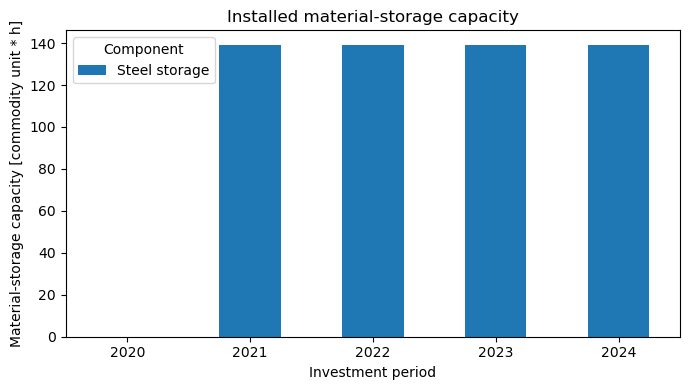

Component,Steel storage
2020,0.00000
2021,139.11524
2022,139.11524
2023,139.11524
2024,139.11524


In [20]:
materialStorageCapacities = {}
for year in esM.investmentPeriodNames:
    summary = esM.getOptimizationSummary(
        "MaterialStorageModel", outputLevel=0, ip=year
    )
    capacity = summary.xs("capacity", level="Property")
    materialStorageCapacities[year] = (
        capacity.groupby(level="Component").sum().sum(axis=1)
    )

materialStorageCapacities = pd.DataFrame(materialStorageCapacities).T.fillna(0)
ax = materialStorageCapacities.plot.bar(
    stacked=True, figsize=(7, 4), rot=0
)
ax.set(
    xlabel="Investment period",
    ylabel="Material-storage capacity [commodity unit * h]",
    title="Installed material-storage capacity",
)
plt.tight_layout()
plt.show()
materialStorageCapacities


In [21]:
tolerance = 1e-6
if materialStorageCapacities.abs().to_numpy().max() <= tolerance:
    print("Elastic material supply does not require storage.")
else:
    print("Material storage is built in at least one investment period.")


Material storage is built in at least one investment period.


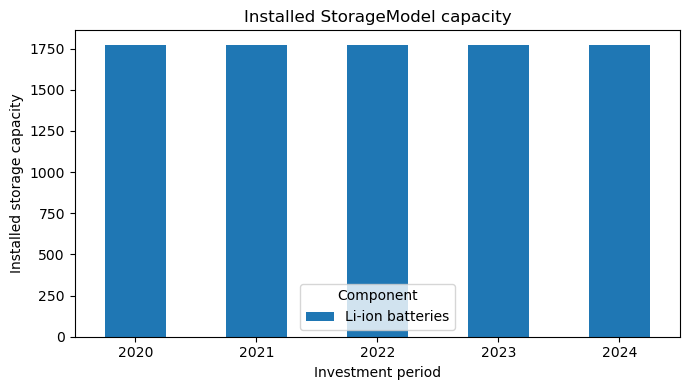

Component,Li-ion batteries
2020,1771.761228
2021,1771.761228
2022,1771.761228
2023,1771.761228
2024,1771.761228


In [22]:
storageCapacities = {}
for year in esM.investmentPeriodNames:
    summary = esM.getOptimizationSummary(
        "StorageModel", outputLevel=0, ip=year
    )
    capacity = summary.xs("capacity", level="Property")
    storageCapacities[year] = (
        capacity.groupby(level="Component").sum().sum(axis=1)
    )

storageCapacities = pd.DataFrame(storageCapacities).T.fillna(0)
ax = storageCapacities.plot.bar(stacked=True, figsize=(7, 4), rot=0)
ax.set(
    xlabel="Investment period",
    ylabel="Installed storage capacity",
    title="Installed StorageModel capacity",
)
plt.tight_layout()
plt.show()
storageCapacities


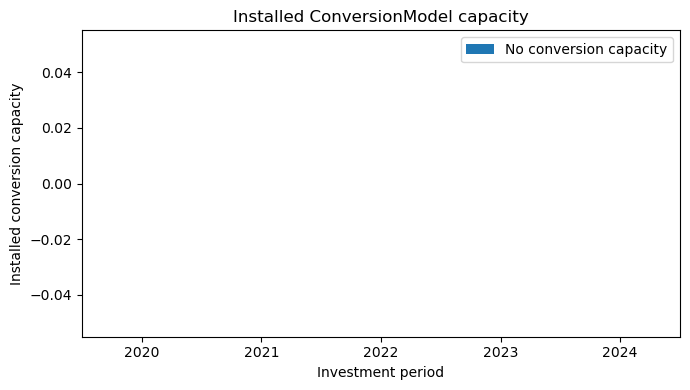

,No conversion capacity
2020,0.0
2021,0.0
2022,0.0
2023,0.0
2024,0.0


In [23]:
if "ConversionModel" in esM.componentModelingDict:
    conversionCapacities = {}
    for year in esM.investmentPeriodNames:
        summary = esM.getOptimizationSummary(
            "ConversionModel", outputLevel=0, ip=year
        )
        capacity = summary.xs("capacity", level="Property")
        conversionCapacities[year] = (
            capacity.groupby(level="Component").sum().sum(axis=1)
        )
    conversionCapacities = pd.DataFrame(conversionCapacities).T.fillna(0)
else:
    conversionCapacities = pd.DataFrame(
        {"No conversion capacity": 0.0},
        index=esM.investmentPeriodNames,
    )

ax = conversionCapacities.plot.bar(stacked=True, figsize=(7, 4), rot=0)
ax.set(
    xlabel="Investment period",
    ylabel="Installed conversion capacity",
    title="Installed ConversionModel capacity",
)
plt.tight_layout()
plt.show()
conversionCapacities


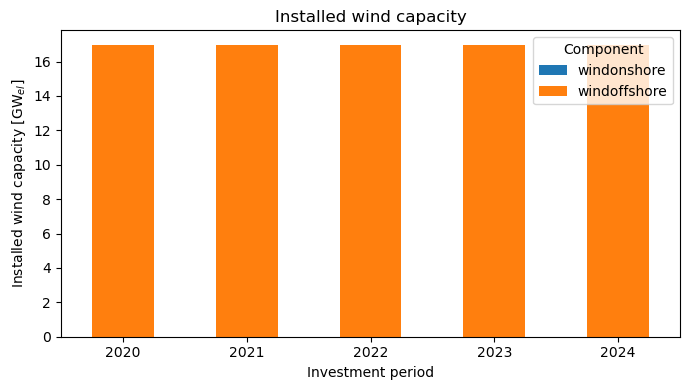

Component,windonshore,windoffshore
2020,0.0,16.965273
2021,0.0,16.965273
2022,0.0,16.965273
2023,0.0,16.965273
2024,0.0,16.965273


In [24]:
windCapacities = {}
for year in esM.investmentPeriodNames:
    summary = esM.getOptimizationSummary(
        "SourceSinkModel", outputLevel=0, ip=year
    )
    capacity = summary.xs("capacity", level="Property")
    capacity = capacity.groupby(level="Component").sum().sum(axis=1)
    windCapacities[year] = capacity.reindex(
        ["windonshore", "windoffshore"], fill_value=0
    )

windCapacities = pd.DataFrame(windCapacities).T.fillna(0)
ax = windCapacities.plot.bar(stacked=True, figsize=(7, 4), rot=0)
ax.set(
    xlabel="Investment period",
    ylabel=r"Installed wind capacity [GW$_{el}$]",
    title="Installed wind capacity",
)
plt.tight_layout()
plt.show()
windCapacities


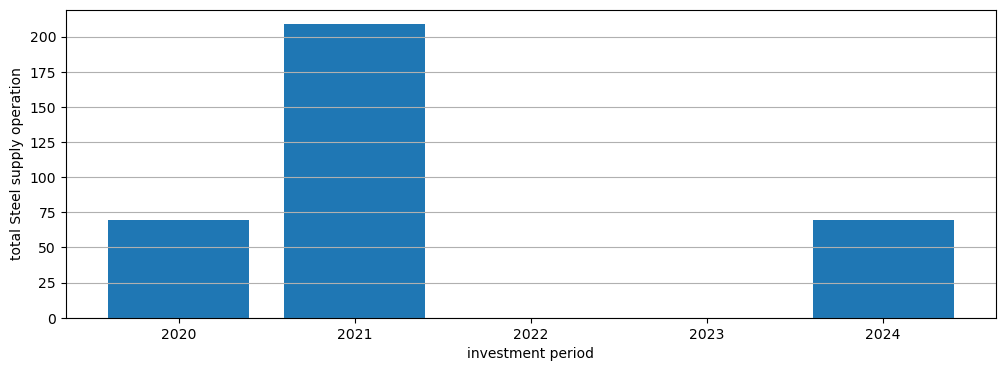

In [25]:
from materialStorageVisualization import (
    plotMaterialStorageOperation,
    plotSourceSinkOperation,
    plotSteelDemandCoverage,
)


fig, ax = plotSourceSinkOperation(
    esM, "Steel supply", style="annualTotals"
)

In [26]:
operation = (
    esM.componentModelingDict["SourceSinkModel"]
    .operationVariablesOptimum[2024]
    .loc[("Steel supply", "GermanyRegion")]
)
operation

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
8755    0.0
8756    0.0
8757    0.0
8758    0.1
8759    0.0
Name: (Steel supply, GermanyRegion), Length: 8760, dtype: float64

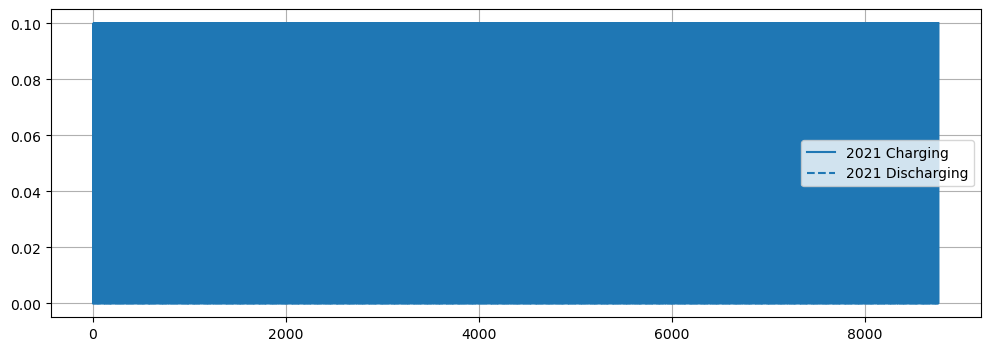

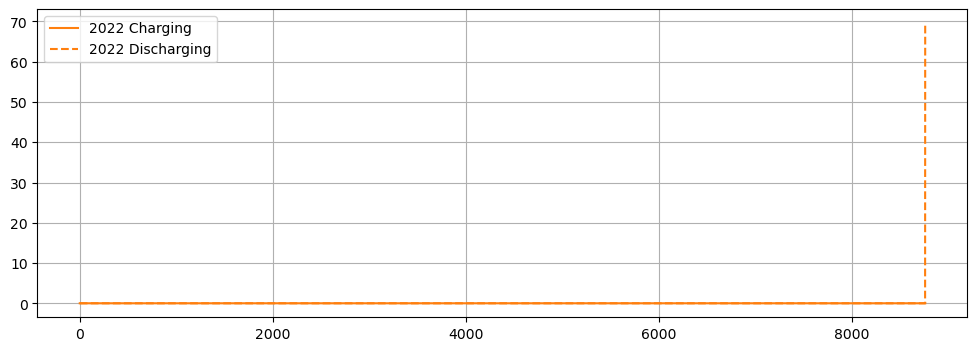

In [27]:
fig, ax = plotMaterialStorageOperation(
    esM, [2021, 2022], separatePlots=True
)

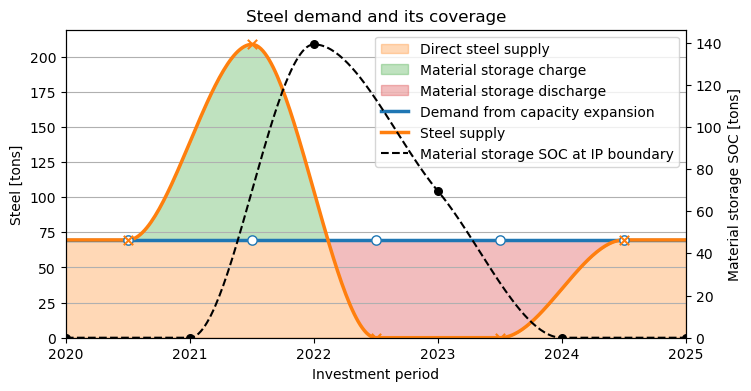

In [32]:
fig, ax = plotSteelDemandCoverage(esM, plotStyle="smooth")

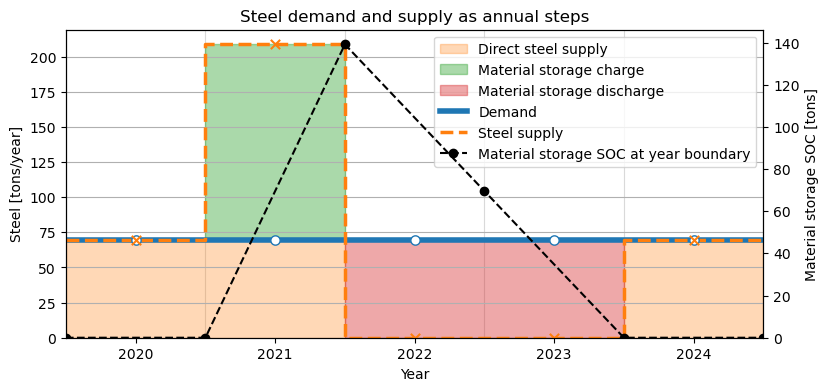

In [33]:
fig, ax = plotSteelDemandCoverage(esM, plotStyle="steps")